# **Roadmap**
- **1-Definition du problème**
- **2-Import dees packages**
- **3-Chargement des données**
- **4-Préparaion des données**
- **5-Analyse Exploratoire des données**
- **6-Entrainement des Modèles**
- **7- Evaluation du modèle**
- **8- Sauvegarde du meilleur Modèle**
- **9- Explication du modèle**
- **10- EvidentlyAI**

## 1-Definition du problème

Classification binaire des objets sous-marins en fonction de leur type : **R** pour roche et **M** pour mines.

## 2-Import des packages

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

import joblib
import shap

from evidently.report import Report
from evidently.metric_preset import DataDriftPreset, ClassificationPreset
import pandas as pd

## 3-Chargement des données

In [3]:
# Extraction des données sans traiter la première ligne comme un header
df = pd.read_csv('./dataset/sonar.all-data.csv',header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


## 4-Préparaion des données

In [4]:
# Renommages des colonnes
column_names = [f'C{i}' for i in range(1, 61)] + ['target']
df.columns = column_names

print(df.head())

       C1      C2      C3      C4      C5      C6      C7      C8      C9  \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

      C10  ...     C52     C53     C54     C55     C56     C57     C58  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

      C59     C60  target  
0  0.0090  0.0032       R  
1  0.0052  0.0044       R  
2  0.009

**Note:** Le dataset contient 60 signatures spectrales. Il n'y apas de valeurs manquantes, on passe directement à l'analyse sans étape d'imputation.

## 5-Analyse Exploratoire des données

In [5]:
# Information sur le jeu de données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   C1      208 non-null    float64
 1   C2      208 non-null    float64
 2   C3      208 non-null    float64
 3   C4      208 non-null    float64
 4   C5      208 non-null    float64
 5   C6      208 non-null    float64
 6   C7      208 non-null    float64
 7   C8      208 non-null    float64
 8   C9      208 non-null    float64
 9   C10     208 non-null    float64
 10  C11     208 non-null    float64
 11  C12     208 non-null    float64
 12  C13     208 non-null    float64
 13  C14     208 non-null    float64
 14  C15     208 non-null    float64
 15  C16     208 non-null    float64
 16  C17     208 non-null    float64
 17  C18     208 non-null    float64
 18  C19     208 non-null    float64
 19  C20     208 non-null    float64
 20  C21     208 non-null    float64
 21  C22     208 non-null    float64
 22  C2

In [6]:
# Statistiques descriptive
df.describe()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C51,C52,C53,C54,C55,C56,C57,C58,C59,C60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


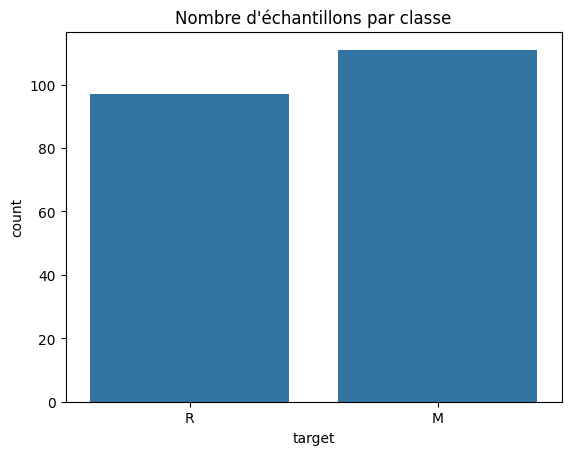

In [7]:
# Visualisation de la répartition des classes
sns.countplot(x='target', data=df)
plt.title("Nombre d'échantillons par classe")
plt.show()

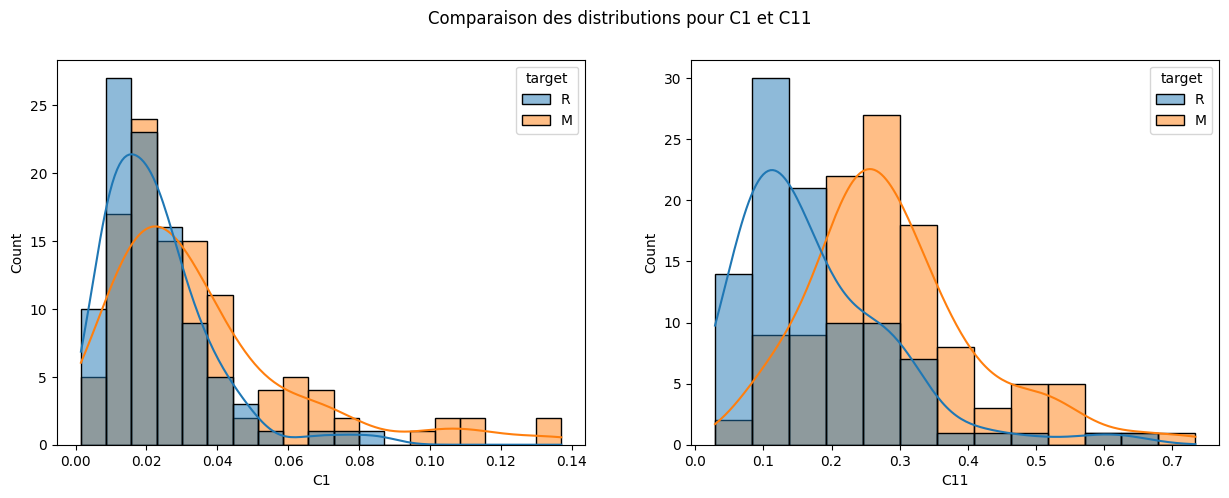

In [8]:
# Distribution de quelques colonnes pour comparer R et M
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df, x='C1', hue='target', kde=True, ax=axes[0])
sns.histplot(data=df, x='C11', hue='target', kde=True, ax=axes[1])
plt.suptitle("Comparaison des distributions pour C1 et C11")
plt.show()

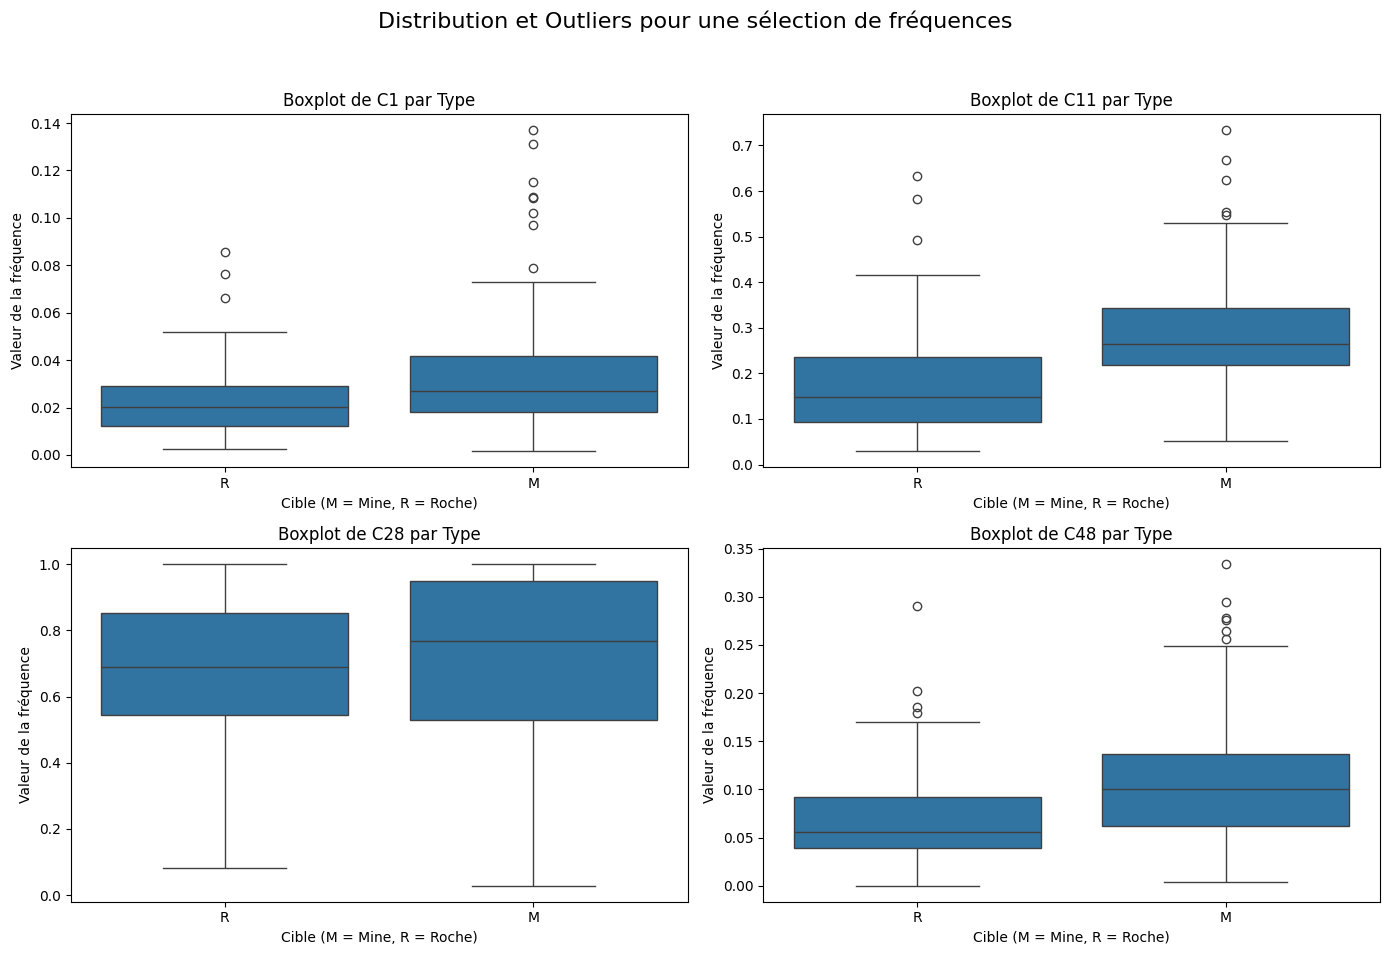

In [9]:
# Liste des colonnes à visualiser
selected_features = ['C1', 'C11', 'C28', 'C48']

# Création d'une figure avec une grille 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution et Outliers pour une sélection de fréquences', fontsize=16)

# Génération des boxplots
for i, col in enumerate(selected_features):
    row = i // 2
    col_idx = i % 2
    sns.boxplot(ax=axes[row, col_idx], x='target', y=col, data=df)
    axes[row, col_idx].set_title(f'Boxplot de {col} par Type')
    axes[row, col_idx].set_xlabel('Cible (M = Mine, R = Roche)')
    axes[row, col_idx].set_ylabel('Valeur de la fréquence')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Note:**
 - Équilibre des classes : Les classes 'M' (Mine) et 'R' (Roche) sont équilibrées
 - StandardScaler est utilisé pour uniformiser les 60 fréquences pour aider les modèles linéaires (Logistic Regression) à converger.**
 - Les valeurs étant toutes en entier, seul la varibale cible a besoin d'être encoder.


## 6-Entrainement des Modèles

In [10]:
# 1. Encodage de la variable cible (M = 1, R = 0 par exemple)
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

# 2. Séparation des caractéristiques (X) et de la cible (y)
X = df.drop(columns=['target'])
y = df['target']

# 3. Division en train/test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Taille du train set : {X_train.shape}")
print(f"Taille du test set : {X_test.shape}")
print("Classes encodées :", dict(zip(le.classes_, le.transform(le.classes_))))

Taille du train set : (166, 60)
Taille du test set : (42, 60)
Classes encodées : {'M': 0, 'R': 1}


**Note:**
- Il est nécessaire d'encoder les étiquettes avant de les passer au modèles.
- Le scaling est appliqué car certains modèles (comme la Régression Logistique) sont sensibles à l'échelle des variables. Cela assure une convergence plus rapide.
- Une Pipeline est utilisé pour éviter la fuite de données (data leakage) et GridSearchCV pour automatiser la recherche des meilleurs hyperparamètres pour chaque modèle.
- F1-score est priviligié pour vérifier la performance des modèles dans la détection de mines, nous voulons un bon équilibre entre la Précision et le Rappel (ne pas manquer une mine, tout en évitant les fausses alertes).

In [11]:
# 1. Configuration des modèles et de leurs hyperparamètres
models_config = [
    {
        'name': 'Logistic Regression',
        'pipeline': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
        'params': {'clf__C': [0.1, 1, 10]}
    },
    {
        'name': 'Random Forest',
        'pipeline': Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(random_state=42))]),
        'params': {'clf__n_estimators': [50, 100], 'clf__max_depth': [None, 10, 20]}
    },
    {
        'name': 'Decision Tree',
        'pipeline': Pipeline([('scaler', StandardScaler()), ('clf', DecisionTreeClassifier(random_state=42))]),
        'params': {'clf__max_depth': [5, 10, None]}
    }
]

best_model = None
best_score = 0

# 2. Boucle d'entraînement et d'évaluation
for item in models_config:
    print(f"\n--- Entraînement de : {item['name']} ---")
    
    # Configuration du GridSearch
    grid = GridSearchCV(item['pipeline'], item['params'], cv=5, scoring='f1_weighted')
    grid.fit(X_train, y_train)
    
    # Évaluation sur le set de test
    current_model = grid.best_estimator_
    y_pred = current_model.predict(X_test)
    
    # Affichage des résultats
    print(f"Meilleurs paramètres : {grid.best_params_}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    # Sauvegarde du meilleur modèle global
    current_score = grid.best_score_
    if current_score > best_score:
        best_score = current_score
        best_model = current_model
        best_model_name = item['name']

print(f" Meilleuir modèle : {best_model_name} avec un score de {best_score:.4f}")



--- Entraînement de : Logistic Regression ---
Meilleurs paramètres : {'clf__C': 0.1}
              precision    recall  f1-score   support

           M       0.78      0.95      0.86        22
           R       0.93      0.70      0.80        20

    accuracy                           0.83        42
   macro avg       0.86      0.83      0.83        42
weighted avg       0.85      0.83      0.83        42


--- Entraînement de : Random Forest ---
Meilleurs paramètres : {'clf__max_depth': None, 'clf__n_estimators': 50}
              precision    recall  f1-score   support

           M       0.79      1.00      0.88        22
           R       1.00      0.70      0.82        20

    accuracy                           0.86        42
   macro avg       0.89      0.85      0.85        42
weighted avg       0.89      0.86      0.85        42


--- Entraînement de : Decision Tree ---
Meilleurs paramètres : {'clf__max_depth': 5}
              precision    recall  f1-score   support

     

## 7- Evaluation du modèle

Les classification report montrent que le meilleur modèle est le Random Forest avec un score de 83% . Il est donc le modèle qu'on va garder.

## 8- Sauvegarde du meilleur Modèle

In [ ]:
folder_name = "models"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    
model_filename = f"{folder_name}/best_model_sonar.joblib"

# Sauvegarde finale pour l'API
joblib.dump(best_model, model_filename,compress=3)
joblib.dump(le, f"{folder_name}/label_encoder_sonar.joblib",compress=3)

## 9- Explication du modèle

In [13]:
print(best_model.steps)

[('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=50, random_state=42))]


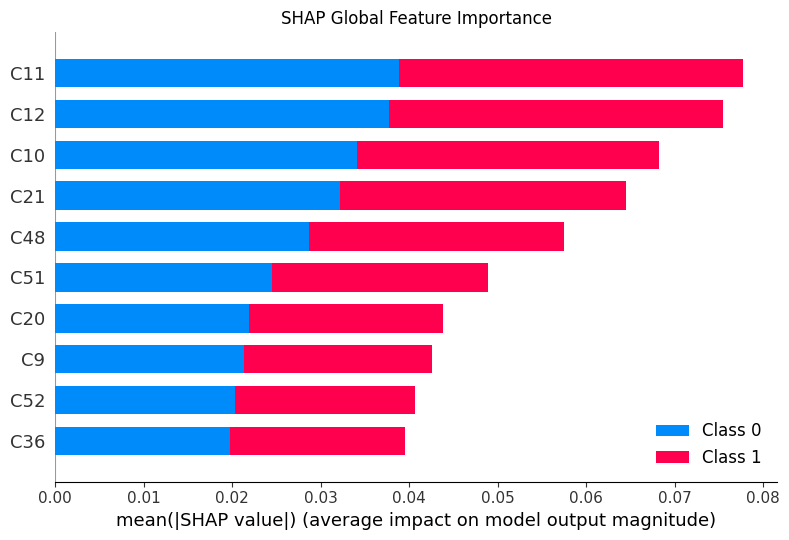

In [14]:
scaler = best_model.named_steps['scaler']
rf_model = best_model.named_steps['clf']

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# Unifier le format SHAP pour multi-classe / binaire
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    shap_values_list = shap_values

feature_names = [f"C{i+1}" for i in range(X_test_scaled.shape[1])]

# summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_list,
    X_test_scaled,
    feature_names=feature_names,
    plot_type="bar",
    max_display=10,
    show=False
)
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.show()


**Note:**
Ce graphique classe les fréquences sonar de haut en bas selon leur influence sur la décision du modèle.Les points s'étalant vers la droite indiquent une influence vers la classification Mine,tandis que ceux vers la gauche poussent le modèle à prédire une Roche. La couleur des points montre que pour les fréquences dominantes, une forte amplitude (en rouge) est généralement le signe caractéristique d'un objet métallique (Mine), validant ainsi la logique physique de l'IA

## 10- EvidentlyAI

### Analyse du drift de données et de la performance du modèle avec Evidently AI

Objectif : Analyser le drift entre les données d'entraînement et de test, ainsi que pour évaluer la performance du modèle de classification.

In [ ]:
# Préparation des DataFrames pour Evidently
feature_names = [f"C{i+1}" for i in range(X_train.shape[1])]

# DataFrame de référence (Train)
train_df = pd.DataFrame(X_train, columns=feature_names)
train_df['target'] = y_train.values if hasattr(y_train, 'values') else y_train
train_df['prediction'] = best_model.predict(X_train)

# DataFrame actuel (Test)
test_df = pd.DataFrame(X_test, columns=feature_names)
test_df['target'] = y_test.values if hasattr(y_test, 'values') else y_test
test_df['prediction'] = best_model.predict(X_test)

print("DataFrames préparés pour Evidently AI")
print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

DataFrames préparés pour Evidently AI
Train shape: (166, 62), Test shape: (42, 62)


In [16]:
# Création du rapport Evidently
report = Report(metrics=[
    DataDriftPreset(),
    ClassificationPreset()
])

print("Génération du rapport Evidently AI...")
report.run(reference_data=train_df, current_data=test_df)
print("Rapport généré avec succès.")

Génération du rapport Evidently AI...
Rapport généré avec succès.


In [20]:
# Sauvegarde du rapport en HTML
report.save_html("monitoring/monitoring_train_test.html")
print("Rapport Evidently AI sauvegardé sous : monitoring_train_test.html")

Rapport Evidently AI sauvegardé sous : monitoring_train_test.html
